## Regression Models



In [1]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


E.T.L

In [2]:
df = pd.read_csv('grades.csv')

In [3]:
df.shape

(1000, 3)

In [4]:
df.head()

,Student ID,Hours Studied,Grade
0,#25074,39,58.50
1,#25083,21,35.00
2,#25130,33,90.51
3,#25221,25,37.50
4,#25257,27,63.79


In [5]:
del df['Student ID']

In [6]:
df.describe()

,Hours Studied,Grade
count,1000.00000,1000.000000
mean,27.84000,60.978750
std,7.53121,20.435529
min,15.00000,20.000000
25%,21.00000,45.000000
50%,28.00000,59.100000
75%,35.00000,75.600000
max,40.00000,100.000000


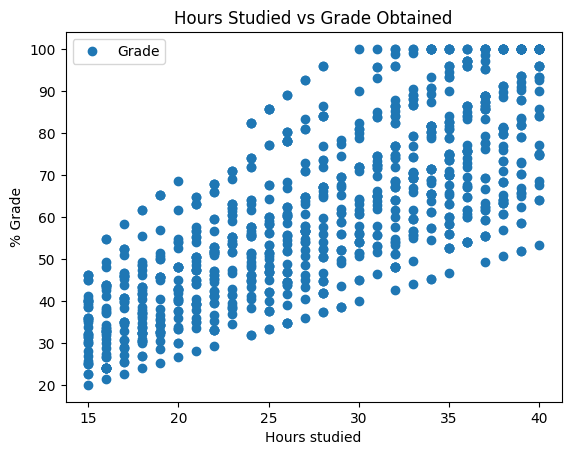

In [7]:
df.plot(x='Hours Studied',y='Grade', style='o')
plt.title('Hours Studied vs Grade Obtained')
plt.xlabel('Hours studied')
plt.ylabel('% Grade')
plt.show()

In [8]:
# We can check the correlation between the two

corr = df['Hours Studied'].corr(df['Grade'])
corr

np.float64(0.7634104863174767)

We can see there is a clear positive correlation between Hours Studied and Grade obtained.

We now split our data into features and labels - the feature here is 'Hours Studied' and the grades are data 'labels'

In [9]:
df.iloc[:, :-1]

,Hours Studied
0,39
1,21
2,33
3,25
4,27
...,...
995,37
996,24
997,35
998,28


In [10]:
# extract the feature & label into arrays

X = df.iloc[:, :-1].values # hours studied
y = df.iloc[:, 1].values # grade

In [11]:
# Split data into training / test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
# Create a model instance

model = LinearRegression()

In [13]:
# Train the model

model.fit(X_train, y_train)

LinearRegression()

In [14]:
print('Intercept:', model.intercept_)
print('Coefficient:', model.coef_)

Intercept: 3.1142253812283442
Coefficient: [2.06755333]


In [15]:
# Make grade predictions

y_pred = model.predict(X_test)

In [16]:
# View predcitions

df_pred = pd.DataFrame({'Actual grade:': y_test, "Predicted:": y_pred})
df_pred

,Actual grade:,Predicted:
0,63.33,81.681252
1,42.93,50.667952
2,44.80,61.005719
3,48.00,69.275932
4,89.14,56.870612
...,...,...
195,42.00,61.005719
196,73.29,81.681252
197,71.74,67.208379
198,68.25,56.870612


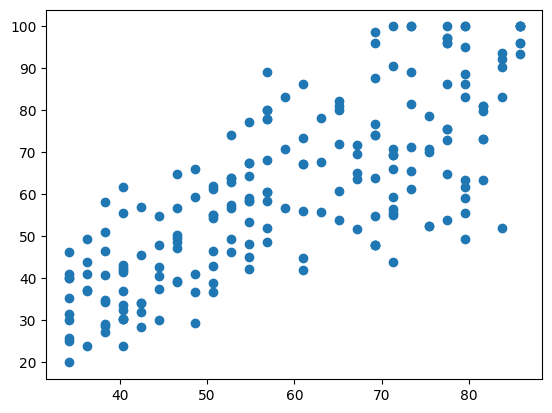

In [17]:
# Plot the data points
plt.scatter(y_pred, y_test, label='Data points')
plt.show()

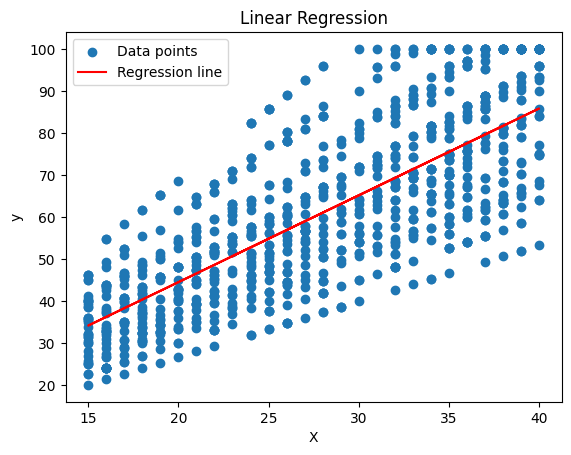

In [18]:


# Plot the data points
plt.scatter(X, y, label='Data points')

# Plot the regression line
plt.plot(X_test, y_pred, color='red', label='Regression line')

# Add labels and title
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()

# Show the plot
plt.show()

We need to evaluate the performance of the algorithm.  How well does it do?

1. Mean Absolute Error
2. Mean Square Error
3. Root Mean Square Error

In [19]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 10.837006376423693
Mean Squared Error: 173.88542716725118
Root Mean Squared Error: 13.18656237111292


In [20]:
y_test.mean()*.15


np.float64(9.127529999999998)

Given a RMSE of 13.65 is more than the 10% of the Mean Score, this model isn't great, but if we visualise the data we can see quite a wide spread from the linear model which is describing the average relationship between Hours Studied and Grade obtained.

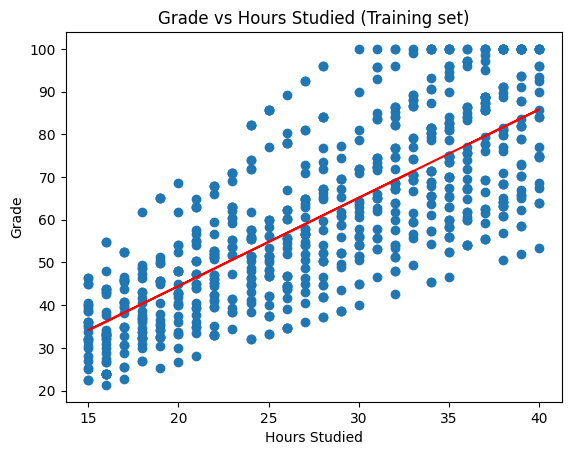

In [21]:
plt.scatter(X_train, y_train)
plt.plot(X_train, model.predict(X_train), color = "red")
plt.title("Grade vs Hours Studied (Training set)")
plt.xlabel("Hours Studied")
plt.ylabel("Grade")
plt.show()

In [22]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)
print('Adjusted R2_score:',(
    1-(1-r2_score(y_test, y_pred))*((len(X_test)-1)/(len(X_test)-len(X_test[0])-1))))

Adjusted R2_score: 0.5914627945065454


The Adjusted R2 - how much of the variability in grade is explained by number of hours studied?   About 55%

## Multiple Linear Regression

We now expand our data set to include several features, which we will map to our label - the grade.

This is more realistic of real life in which several factors influence a dependent variable.

We extend our grades dataset to include the following features:
* Number of Hours Studied
* Number of Hours Sleep the student reported having in the week prior to the exam
* The number of extention assignments the student completed
* The distance the student lives from campus

The label - Grade - remains the same.

We will now conduct a supervised machine learning analysis - in which we map the inputs (feature values) to the label (grade).  Remember we want to develop a model that captures the average relationship between the features and the label.  

In [23]:
data = pd.read_csv('grades_multi.csv')

In [24]:
print(data.shape)
data.head()

(1000, 6)


,Student ID,Hours Studied,Hours Sleep,Number of Assignments,Distance from College,Grade
0,#25074,39,40,5,2.14,58.50
1,#25083,21,47,3,7.54,35.00
2,#25130,33,61,8,20.82,90.51
3,#25221,25,25,4,0.45,37.50
4,#25257,27,50,6,2.53,63.79


In [25]:
# we can drop the 'Student ID' column

del data['Student ID']

In [26]:
# Inspect our data - EDA

data.describe()

,Hours Studied,Hours Sleep,Number of Assignments,Distance from College,Grade
count,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000
mean,27.84000,52.098000,5.503000,4.29492,60.978750
std,7.53121,15.699199,1.902527,6.86062,20.435529
min,15.00000,21.000000,2.000000,0.02000,20.000000
25%,21.00000,40.000000,4.000000,0.86000,45.000000
50%,28.00000,50.000000,5.000000,2.11000,59.100000
75%,35.00000,63.000000,7.000000,4.68750,75.600000
max,40.00000,105.000000,10.000000,108.04000,100.000000


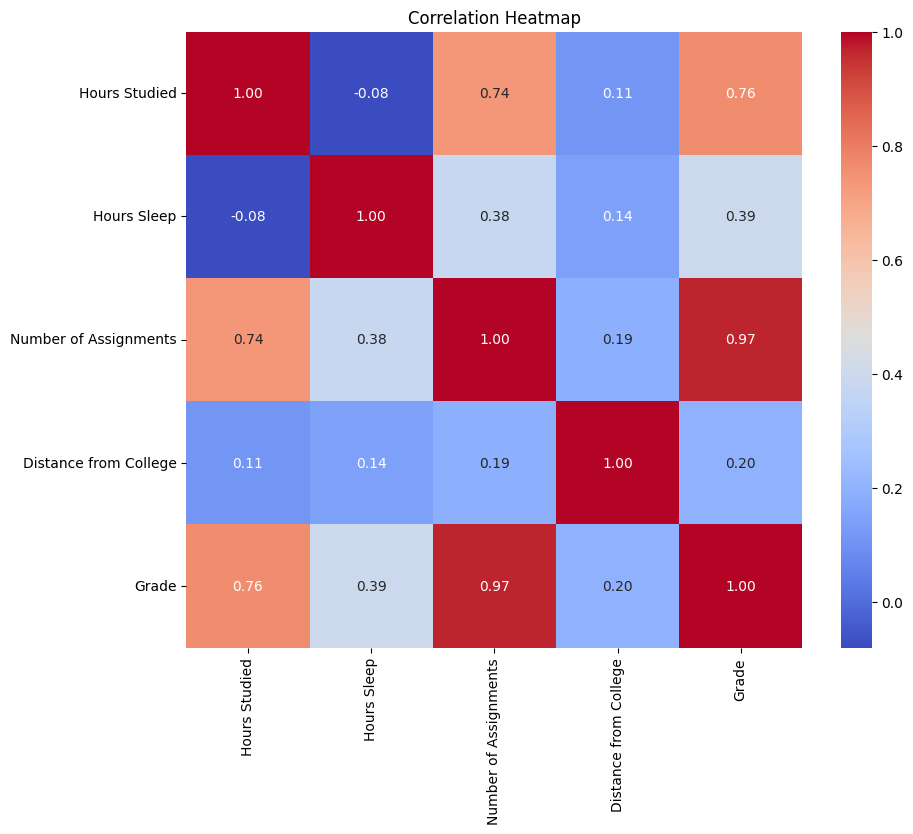

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame
corr = data.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()

Read the bottom row of the correlation matrix to get a feel for the variables with the most explanatory influence.

Notice that Distance from College shows some positive correlation - this could be random, or could be a real relationship.   We would need to test this for statitiscal significance.

<Axes: >

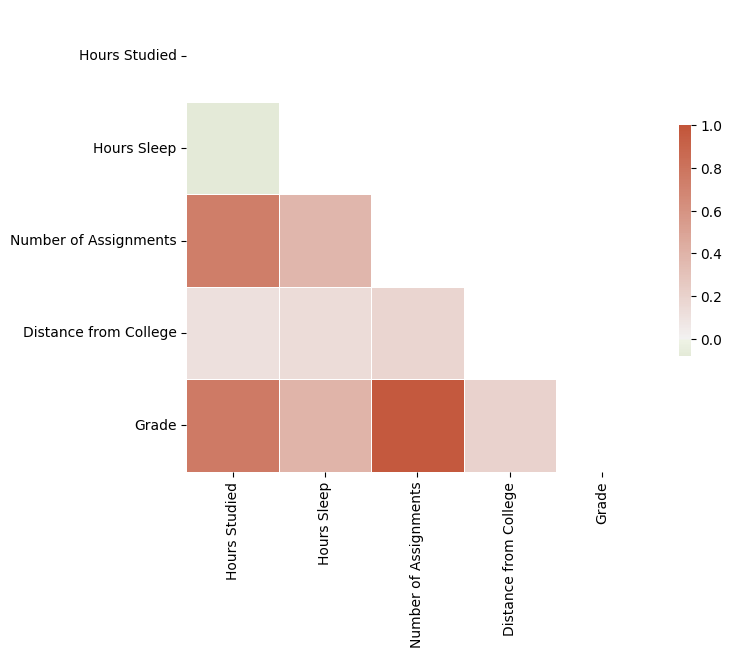

In [28]:
# Set up the heatmap of the correlation matrix to visualize the data
import seaborn as sns

mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(100, 20, as_cmap=True)

f, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, center=0,square=True,
            linewidths=.5, cbar_kws={"shrink": .5})

Look at the bottom row 'Grade' and notice which features correlate


Now we split our data into feature maps and the target output (features and labels)

In [29]:
X = data[['Hours Studied', 'Distance from College', 'Hours Sleep', 'Number of Assignments']]
y = data['Grade']

Create a Train / Test split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Now we can train our model on our training datasets

In [31]:
model = LinearRegression() # create an instance of LinearRegression class
model.fit(X_train, y_train)

LinearRegression()

Inspect the feature co-efficients

In [32]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Hours Studied,0.571222
Distance from College,0.082505
Hours Sleep,0.154067
Number of Assignments,8.132429


Run the test data through the model and make a prediction - we will then compare our predictions to the actual grades in the test set to evaluate model performance

In [33]:
y_pred = model.predict(X_test)

In [34]:
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df

,Actual,Predicted
993,65.14,63.588189
859,99.90,97.573433
298,39.67,42.856547
553,86.40,75.860334
672,46.50,46.817601
...,...,...
679,65.33,54.686280
722,57.60,53.038503
215,22.50,23.017998
653,100.00,98.132936


By the looks of it our model is performing pretty good; we'll need to see some formal metrics...

In [35]:
# calculate the r-squared

from sklearn.metrics import r2_score
r2_score = r2_score(y_test, y_pred)


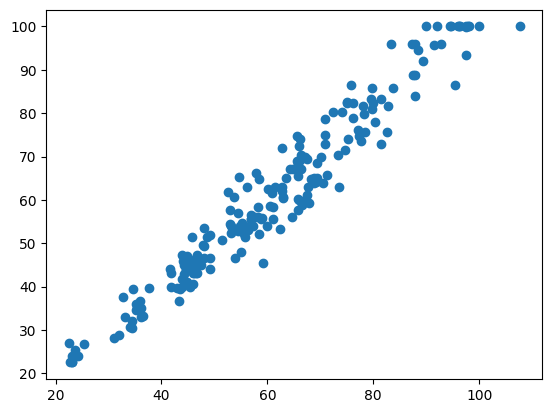

In [36]:
# Plot the data points
plt.scatter(y_pred, y_test, label='Data points')
plt.show()

In [37]:
y_test.mean()*.05


np.float64(3.0230825)

In [38]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R-squared:', r2_score)
print()
print('10% of the Mean of Grade:', data['Grade'].mean()*0.1)

Mean Absolute Error: 3.6137370457620874
Mean Squared Error: 20.968519194528007
Root Mean Squared Error: 4.579139569234378
R-squared: 0.9483204285127416

10% of the Mean of Grade: 6.097875


If our RMSE < 10% of the Mean Score for Grades, then we have a good model.

In addition, we can see we have a high R-squared which suggests our model variables explain most of the variability in the grade - but we should be wary of spurrious correlation.